# 01 - EDA Completa dos Dados de Knowledge Tracing

Este notebook consolida a análise exploratória completa dos dados do projeto MedQ/KT em um único fluxo.

## Objetivos
- validar a qualidade dos dados raw
- entender a distribuição de questões, respostas e temas
- analisar comportamento temporal dos alunos
- inspecionar granularidade por skill e por H2
- gerar evidências para DKT e LPKT

## Fontes esperadas
- `data/raw/questions.json`
- `data/raw/answers.json`
- `data/raw/tree.json`
- `data/processed/mappings/skill_to_h2.json`


In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from brain_kt.utils.eda_helpers import detect_nested_columns, safe_duplicated_count, safe_log1p

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 140)

RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

QUESTIONS_PATH = RAW_DIR / 'questions.json'
ANSWERS_PATH = RAW_DIR / 'answers.json'
TREE_PATH = RAW_DIR / 'tree.json'
SKILL_TO_H2_PATH = PROCESSED_DIR / 'mappings' / 'skill_to_h2.json'

print('PROJECT_ROOT:', PROJECT_ROOT)
print('QUESTIONS_PATH exists:', QUESTIONS_PATH.exists())
print('ANSWERS_PATH exists:', ANSWERS_PATH.exists())
print('TREE_PATH exists:', TREE_PATH.exists())
print('SKILL_TO_H2_PATH exists:', SKILL_TO_H2_PATH.exists())

PROJECT_ROOT: /Users/primum/primum/ai-core
QUESTIONS_PATH exists: True
ANSWERS_PATH exists: True
TREE_PATH exists: True
SKILL_TO_H2_PATH exists: False


In [2]:
questions = pd.read_json(QUESTIONS_PATH, encoding='latin-1')
answers = pd.read_json(ANSWERS_PATH)

with open(TREE_PATH, 'r', encoding='utf-8') as f:
    tree = json.load(f)

skill_to_h2 = {}
if SKILL_TO_H2_PATH.exists():
    with open(SKILL_TO_H2_PATH, 'r', encoding='utf-8') as f:
        skill_to_h2 = json.load(f)

print('questions:', len(questions))
print('answers:', len(answers))
print('skill_to_h2 entries:', len(skill_to_h2))

questions: 150553
answers: 1289900
skill_to_h2 entries: 0


## 1. Amostras e schema

Inspeção inicial para validar colunas, tipos e formato dos objetos.

In [3]:
display(questions.head(3))
display(answers.head(3))
questions.info()
answers.info()

,_id,subjectId,examYear,institutionName,questionId,subjectAccumulatedNames
0,ddf1a08a-58b3-4985-a634-fd082f32a733,3e7e72aa-1f2d-44c7-b1b2-eaec0a839b5d,2016,ABC,ddf1a08a-58b3-4985-a634-fd082f32a733,"[Cirurgia, Cirurgia geral, Abdome agudo, Litía..."
1,9efc8feb-1ff2-46b1-a94b-fa8cb36f0541,e3741af1-3fa3-4e07-9f6a-3cc93d301f8c,2016,ABC,9efc8feb-1ff2-46b1-a94b-fa8cb36f0541,"[Preventiva, Medicina legal]"
2,ab8855da-f535-4e8b-8851-7489a35bf30f,c9e773ad-43b8-4e77-ad94-eca83400f3e3,2016,ABC,ab8855da-f535-4e8b-8851-7489a35bf30f,[Cirurgia]


,user_id,question_id,skill_id,correct,timestamp,time_response
0,1ee4a612-e2e5-53a8-8400-82c10148aaee,d9a22f0b-fa16-460c-aaf5-0fac8e4ba2cd,4ed96338-2854-4a32-9b3a-b47839c01101,1,2025-12-31 23:59:21.142,20171
1,088f5f83-16af-5183-bdb7-c5d8f022573f,519e47c9-9d51-41a1-8fe8-50ba672abcbc,0d7d0ca4-1cd3-46be-b736-ef55c3ccd834,1,2025-12-31 23:59:16.324,14461
2,7da0fa0c-6e68-5740-9966-f4db23d33158,6a0b9728-af13-4965-b036-c3b86f985df3,61f8310a-0b73-4dc2-863b-774e8ae5962f,0,2025-12-31 23:59:04.138,39139


<class 'pandas.DataFrame'>
RangeIndex: 150553 entries, 0 to 150552
Data columns (total 6 columns):
 #   Column                   Non-Null Count   Dtype 
---  ------                   --------------   ----- 
 0   _id                      150553 non-null  str   
 1   subjectId                110879 non-null  str   
 2   examYear                 150553 non-null  int64 
 3   institutionName          150553 non-null  str   
 4   questionId               150553 non-null  str   
 5   subjectAccumulatedNames  110879 non-null  object
dtypes: int64(1), object(1), str(4)
memory usage: 6.9+ MB
<class 'pandas.DataFrame'>
RangeIndex: 1289900 entries, 0 to 1289899
Data columns (total 6 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   user_id        1289900 non-null  str           
 1   question_id    1289900 non-null  str           
 2   skill_id       1211110 non-null  str           
 3   correct        1289900 non-null  int64  

In [4]:
print('Nested columns in questions:', detect_nested_columns(questions))
print('Nested columns in answers:', detect_nested_columns(answers))

Nested columns in questions: ['subjectAccumulatedNames']
Nested columns in answers: []


## 2. Resumo executivo

Métricas centrais para entender o tamanho e a cobertura do dataset.

In [5]:
summary = pd.Series({
    'n_questions': len(questions),
    'n_answers': len(answers),
    'n_unique_users': answers['user_id'].nunique(),
    'n_unique_question_ids_in_answers': answers['question_id'].nunique(),
    'n_unique_skills_in_answers': answers['skill_id'].nunique(),
    'n_unique_subjects_in_questions': questions['subjectId'].nunique() if 'subjectId' in questions.columns else None,
    'n_unique_institutions': questions['institutionName'].nunique() if 'institutionName' in questions.columns else None,
    'n_unique_exam_years': questions['examYear'].nunique() if 'examYear' in questions.columns else None,
})
summary

n_questions                          150553
n_answers                           1289900
n_unique_users                         1207
n_unique_question_ids_in_answers      73920
n_unique_skills_in_answers              441
n_unique_subjects_in_questions          471
n_unique_institutions                   276
n_unique_exam_years                      11
dtype: int64

## 3. Qualidade dos dados

Análises de nulls, duplicidade e valores inválidos com tratamento seguro para colunas aninhadas.

In [6]:
nulls_questions = questions.isna().sum().sort_values(ascending=False)
nulls_answers = answers.isna().sum().sort_values(ascending=False)
display(nulls_questions[nulls_questions > 0])
display(nulls_answers[nulls_answers > 0])

subjectId                  39674
subjectAccumulatedNames    39674
dtype: int64

skill_id    78790
dtype: int64

In [7]:
duplicated_questions_rows = safe_duplicated_count(
    questions,
    subset=[c for c in ['questionId', 'subjectId', 'institutionName', 'examYear'] if c in questions.columns],
)

quality_report = pd.Series({
    'duplicated_answers_rows': int(answers.duplicated().sum()),
    'duplicated_questions_rows': duplicated_questions_rows,
    'invalid_correct_values': int((~answers['correct'].isin([0, 1])).sum()),
    'negative_time_response': int((answers['time_response'] < 0).sum()),
    'negative_timestamp': int((answers['timestamp'] < 0).sum()),
})
quality_report

TypeError: Invalid comparison between dtype=datetime64[ms] and int

## 4. Distribuição de acertos

Essa etapa ajuda a entender balanceamento do target, algo importante para interpretação de Accuracy e AUC.

In [8]:
correct_dist = answers['correct'].value_counts().sort_index()
correct_ratio = answers['correct'].value_counts(normalize=True).sort_index()
display(correct_dist)
display(correct_ratio)

correct
0    396515
1    893385
Name: count, dtype: int64

correct
0    0.3074
1    0.6926
Name: proportion, dtype: float64

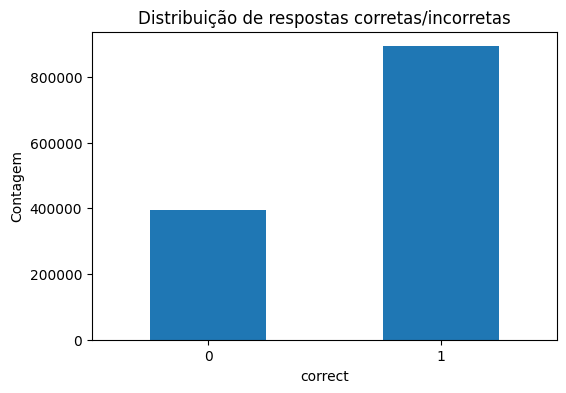

In [9]:
plt.figure(figsize=(6, 4))
correct_dist.plot(kind='bar')
plt.title('Distribuição de respostas corretas/incorretas')
plt.xlabel('correct')
plt.ylabel('Contagem')
plt.xticks(rotation=0)
plt.show()

## 5. Interações por usuário

Knowledge Tracing depende fortemente de sequência. Por isso, é importante medir o tamanho das trajetórias dos alunos.

In [10]:
user_counts = answers.groupby('user_id').size().sort_values(ascending=False)
user_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count     1207.000000
mean      1068.682684
std       1549.389561
min          1.000000
50%        464.000000
75%       1332.000000
90%       2962.400000
95%       4123.000000
99%       6885.320000
max      15195.000000
dtype: float64

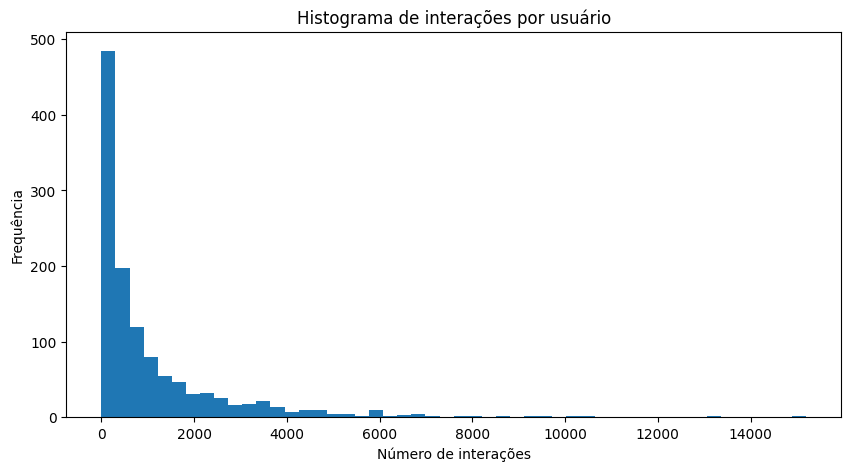

In [11]:
plt.figure(figsize=(10, 5))
plt.hist(user_counts, bins=50)
plt.title('Histograma de interações por usuário')
plt.xlabel('Número de interações')
plt.ylabel('Frequência')
plt.show()

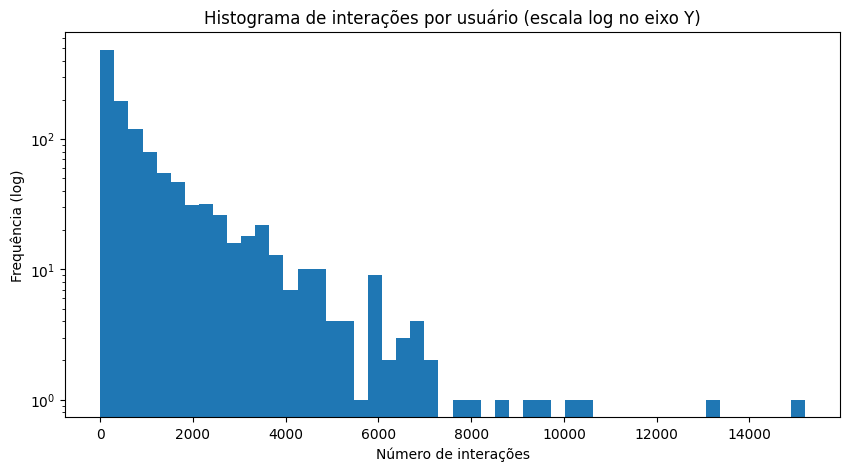

In [12]:
plt.figure(figsize=(10, 5))
plt.hist(user_counts[user_counts > 0], bins=50, log=True)
plt.title('Histograma de interações por usuário (escala log no eixo Y)')
plt.xlabel('Número de interações')
plt.ylabel('Frequência (log)')
plt.show()

In [13]:
thresholds = [1, 2, 5, 10, 20, 50, 100]
coverage = {f'>={t} interações': int((user_counts >= t).sum()) for t in thresholds}
pd.Series(coverage)

>=1 interações      1207
>=2 interações      1196
>=5 interações      1181
>=10 interações     1155
>=20 interações     1120
>=50 interações     1055
>=100 interações     967
dtype: int64

## 6. Cobertura por questão e skill

Aqui avaliamos concentração de respostas em poucas questões ou skills.

In [14]:
question_counts = answers.groupby('question_id').size().sort_values(ascending=False)
skill_counts = answers.groupby('skill_id').size().sort_values(ascending=False)

display(question_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))
display(skill_counts.describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]))

count    73920.000000
mean        17.449946
std         21.067869
min          1.000000
50%          9.000000
75%         23.000000
90%         48.000000
95%         63.000000
99%         92.000000
max        207.000000
dtype: float64

count      441.000000
mean      2746.281179
std       2677.649638
min          1.000000
50%       1893.000000
75%       3960.000000
90%       6292.000000
95%       8286.000000
99%      11532.200000
max      13692.000000
dtype: float64

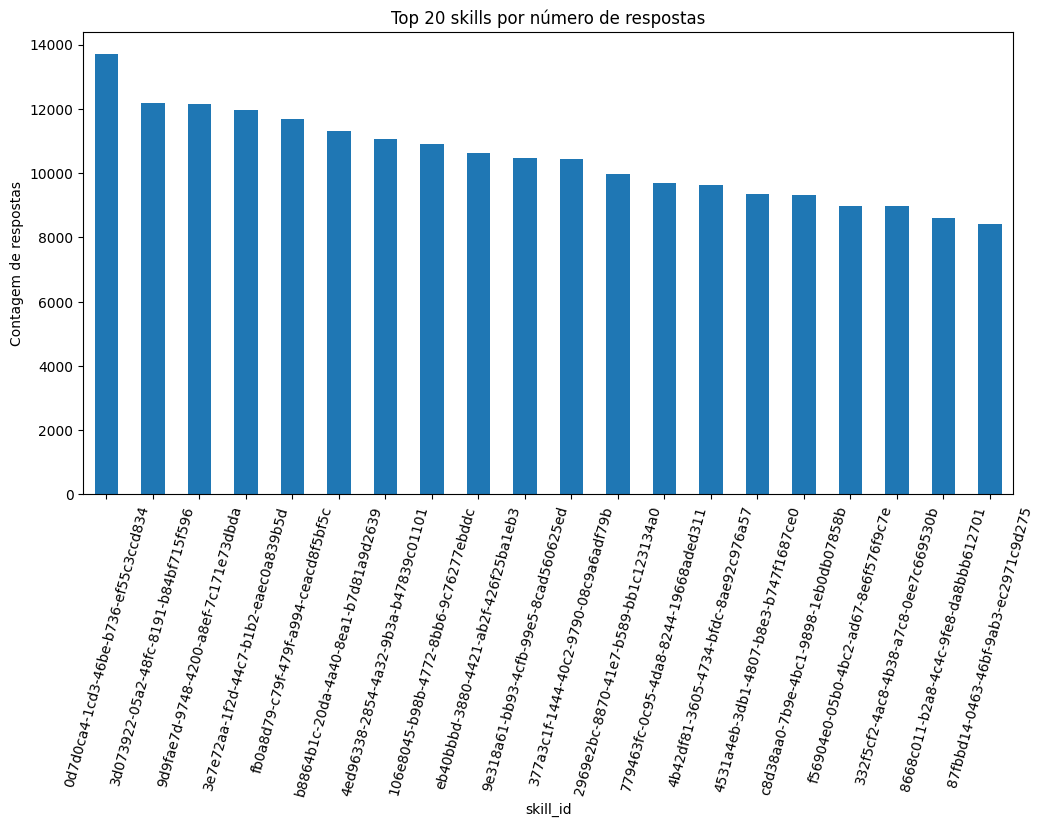

In [15]:
top_skills = skill_counts.head(20)
plt.figure(figsize=(12, 6))
top_skills.plot(kind='bar')
plt.title('Top 20 skills por número de respostas')
plt.xlabel('skill_id')
plt.ylabel('Contagem de respostas')
plt.xticks(rotation=75)
plt.show()

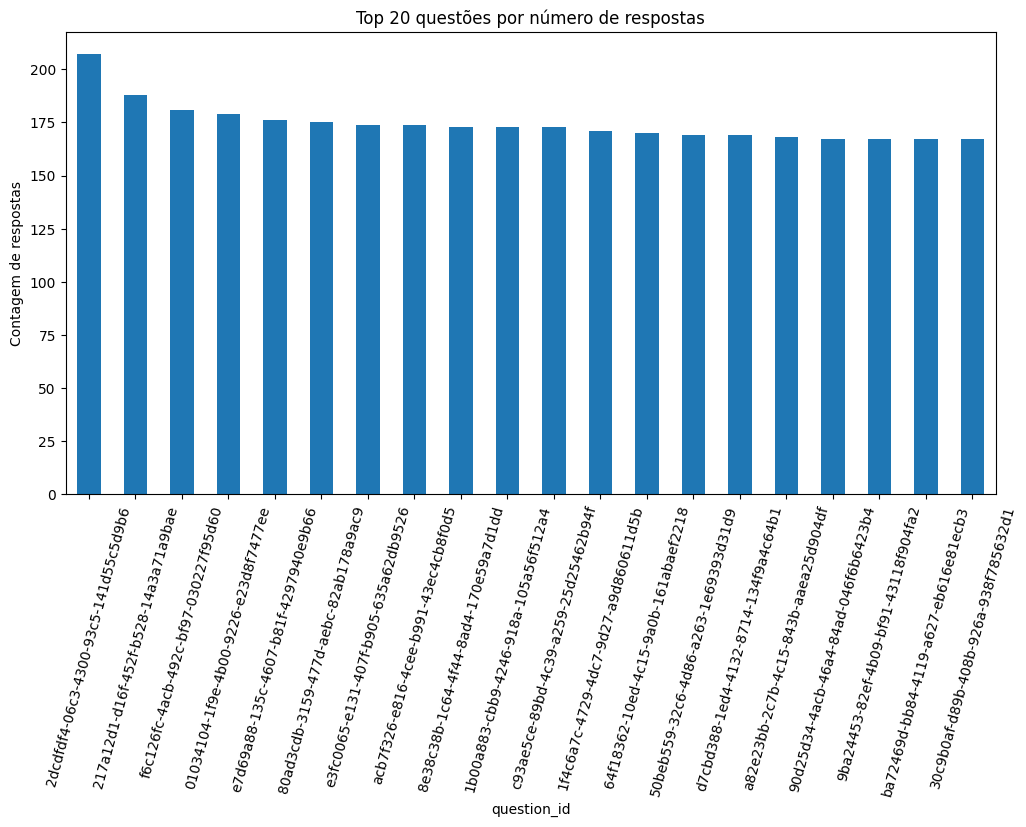

In [16]:
top_questions = question_counts.head(20)
plt.figure(figsize=(12, 6))
top_questions.plot(kind='bar')
plt.title('Top 20 questões por número de respostas')
plt.xlabel('question_id')
plt.ylabel('Contagem de respostas')
plt.xticks(rotation=75)
plt.show()

## 7. Sparsity do problema

Uma medida importante em KT é a densidade observada de interações no espaço usuário-skill.

In [17]:
n_users = answers['user_id'].nunique()
n_skills = answers['skill_id'].nunique()
density = len(answers) / (n_users * n_skills)
pd.Series({
    'n_users': n_users,
    'n_skills': n_skills,
    'n_answers': len(answers),
    'user_skill_density': density,
})

n_users               1.207000e+03
n_skills              4.410000e+02
n_answers             1.289900e+06
user_skill_density    2.423317e+00
dtype: float64

## 8. Tempo de resposta

Tempo de resposta é uma feature importante especialmente para LPKT. Aqui verificamos escala, caudas e necessidade de transformação logarítmica.

In [18]:
answers['time_response'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count    1.289900e+06
mean     4.515946e+06
std      4.576363e+07
min     -3.039811e+09
50%      4.859500e+04
75%      1.518110e+05
90%      2.071019e+06
95%      8.481370e+06
99%      9.491540e+07
max      3.171043e+09
Name: time_response, dtype: float64

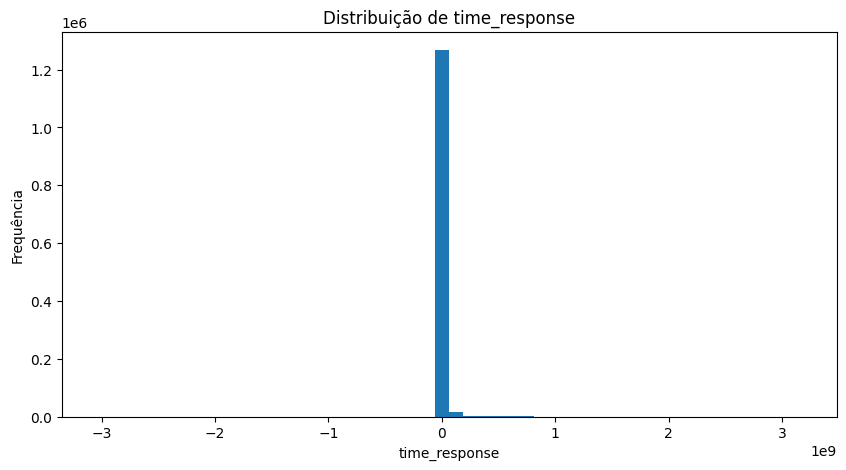

In [19]:
plt.figure(figsize=(10, 5))
plt.hist(answers['time_response'], bins=50)
plt.title('Distribuição de time_response')
plt.xlabel('time_response')
plt.ylabel('Frequência')
plt.show()

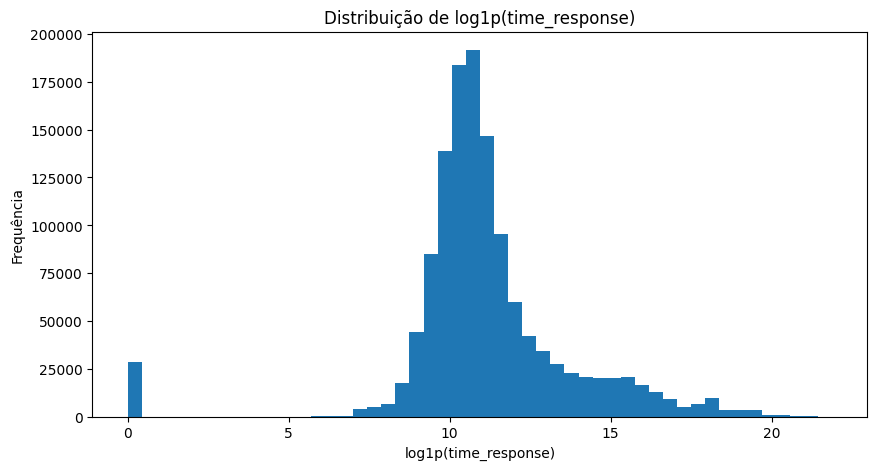

In [20]:
time_log = safe_log1p(answers['time_response'])
plt.figure(figsize=(10, 5))
plt.hist(time_log, bins=50)
plt.title('Distribuição de log1p(time_response)')
plt.xlabel('log1p(time_response)')
plt.ylabel('Frequência')
plt.show()

## 9. Recência / Delta de tempo

A recência entre interações é um dos sinais mais importantes para modelos temporais.

In [21]:
answers_sorted = answers.sort_values(['user_id', 'timestamp']).copy()
answers_sorted['delta_t'] = answers_sorted.groupby('user_id')['timestamp'].diff().fillna(0)
answers_sorted['delta_t'].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])

count             1289900
unique             220453
top       0 days 00:00:00
freq               827166
Name: delta_t, dtype: object

TypeError: '<=' not supported between instances of 'int' and 'Timedelta'

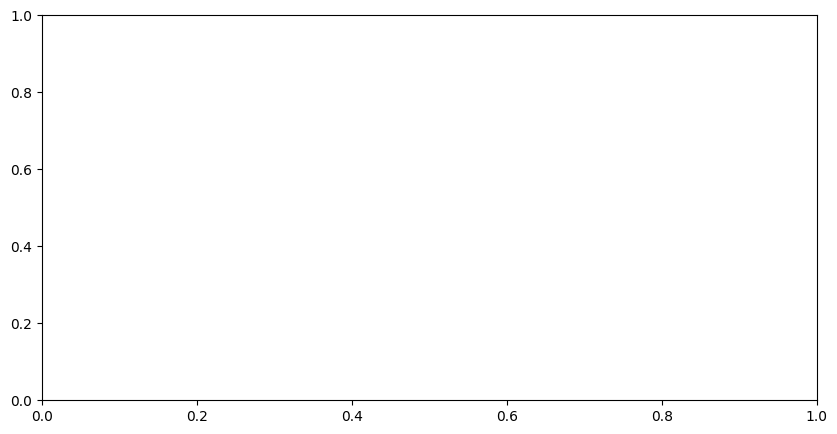

In [22]:
plt.figure(figsize=(10, 5))
plt.hist(answers_sorted['delta_t'], bins=50)
plt.title('Distribuição de delta_t')
plt.xlabel('delta_t')
plt.ylabel('Frequência')
plt.show()

In [ ]:
delta_log = safe_log1p(answers_sorted['delta_t'])
plt.figure(figsize=(10, 5))
plt.hist(delta_log, bins=50)
plt.title('Distribuição de log1p(delta_t)')
plt.xlabel('log1p(delta_t)')
plt.ylabel('Frequência')
plt.show()

TypeError: '>=' not supported between instances of 'Timedelta' and 'int'

## 10. Análise das questões

Aqui avaliamos instituições, anos e profundidade temática.

In [23]:
if 'institutionName' in questions.columns:
    display(questions['institutionName'].value_counts().head(20))

if 'examYear' in questions.columns:
    display(questions['examYear'].value_counts().sort_index())

institutionName
SES-DF                     3380
UNICAMP                    2771
USP-SP                     2460
SCMSP                      2250
SES-PE                     2050
AMP                        2035
INEP-Revalida              2019
Thiago Rosa Institution    1940
AMRIGS                     1930
ABC                        1926
FAMERP                     1760
SURCE                      1728
SES-GO                     1694
UNB                        1640
HCPA                       1602
SES-RJ                     1555
UEPA-BELÉM                 1550
UFRJ                       1548
USP-RP                     1544
SCMBH                      1513
Name: count, dtype: int64

examYear
2016    12097
2017    15083
2018    18256
2019    17262
2020    23750
2021    21795
2022    11918
2023     8893
2024    11404
2025     8350
2026     1745
Name: count, dtype: int64

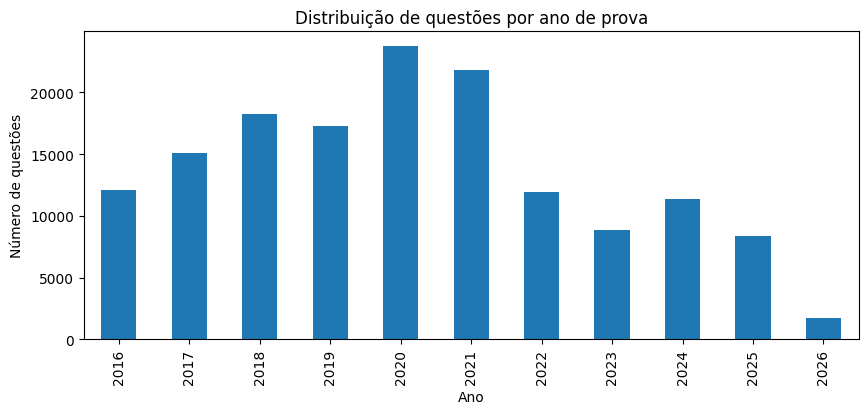

In [24]:
if 'examYear' in questions.columns:
    plt.figure(figsize=(10, 4))
    questions['examYear'].value_counts().sort_index().plot(kind='bar')
    plt.title('Distribuição de questões por ano de prova')
    plt.xlabel('Ano')
    plt.ylabel('Número de questões')
    plt.show()

path_depth
0    39674
1      447
2     5685
3    67245
4    37502
Name: count, dtype: int64

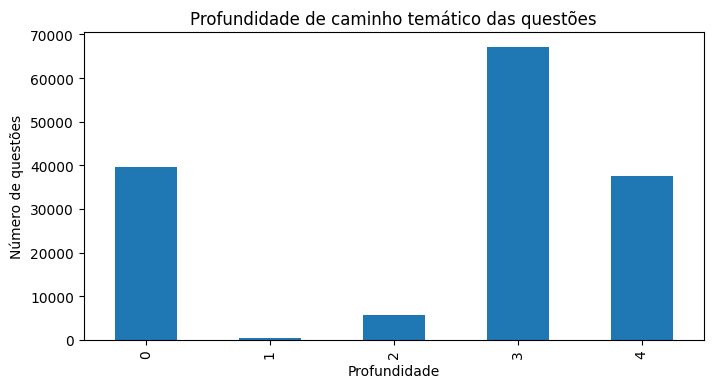

In [25]:
if 'subjectAccumulatedNames' in questions.columns:
    questions['path_depth'] = questions['subjectAccumulatedNames'].apply(lambda x: len(x) if isinstance(x, list) else 0)
    display(questions['path_depth'].value_counts().sort_index())

    plt.figure(figsize=(8, 4))
    questions['path_depth'].value_counts().sort_index().plot(kind='bar')
    plt.title('Profundidade de caminho temático das questões')
    plt.xlabel('Profundidade')
    plt.ylabel('Número de questões')
    plt.show()

## 11. Enriquecimento com H2

Mapeamos skills para H2 para permitir análise pedagógica agregada.

In [26]:
answers_h2 = answers.copy()
if skill_to_h2:
    answers_h2['h2'] = answers_h2['skill_id'].astype(str).map(skill_to_h2)
    h2_coverage = answers_h2['h2'].notna().mean()
    print('H2 coverage on answers:', round(h2_coverage, 4))
    display(answers_h2['h2'].value_counts(dropna=False).head(20))
else:
    print('skill_to_h2.json não encontrado.')

skill_to_h2.json não encontrado.


In [27]:
if skill_to_h2:
    top_h2 = answers_h2['h2'].value_counts().head(20)
    plt.figure(figsize=(12, 6))
    top_h2.plot(kind='bar')
    plt.title('Top 20 H2 por número de respostas')
    plt.xlabel('H2')
    plt.ylabel('Contagem de respostas')
    plt.xticks(rotation=75)
    plt.show()

In [28]:
if skill_to_h2:
    h2_acc = answers_h2.dropna(subset=['h2']).groupby('h2')['correct'].agg(['mean', 'count']).sort_values('count', ascending=False)
    display(h2_acc.head(20))

    top_h2_acc = h2_acc.head(15).sort_values('mean', ascending=False)
    plt.figure(figsize=(12, 6))
    plt.bar(top_h2_acc.index, top_h2_acc['mean'])
    plt.title('Acurácia média por H2 (top 15 por volume)')
    plt.xlabel('H2')
    plt.ylabel('Taxa média de acerto')
    plt.xticks(rotation=75)
    plt.ylim(0, 1)
    plt.show()

## 12. Acurácia por skill

Esse recorte ajuda a entender heterogeneidade de dificuldade entre skills.

In [29]:
skill_acc = answers.groupby('skill_id')['correct'].agg(['mean', 'count']).sort_values('count', ascending=False)
display(skill_acc.head(20))

,mean,count
skill_id,,
0d7d0ca4-1cd3-46be-b736-ef55c3ccd834,0.727797,13692
3d073922-05a2-48fc-8191-b84bf715f596,0.704898,12189
9d9fae7d-9748-4200-a8ef-7c171e73dbda,0.654580,12162
3e7e72aa-1f2d-44c7-b1b2-eaec0a839b5d,0.667502,11967
fb0a8d79-c79f-479f-a994-ceacd8f5bf5c,0.705006,11685
b8864b1c-20da-4a40-8ea1-b7d81a9d2639,0.743696,11303
4ed96338-2854-4a32-9b3a-b47839c01101,0.653637,11052
106e8045-b98b-4772-8bb6-9c76277ebddc,0.748923,10905
eb40bbbd-3880-4421-ab2f-426f25ba1eb3,0.677544,10634


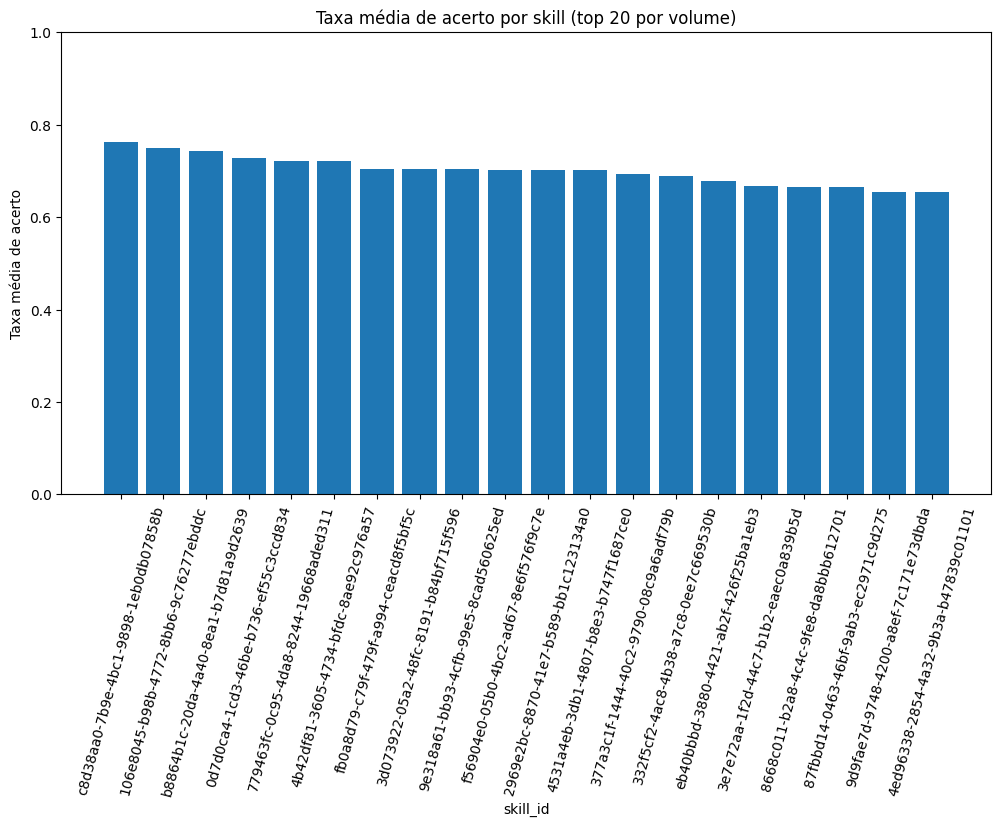

In [30]:
skill_acc_top = skill_acc.head(20).sort_values('mean', ascending=False)
plt.figure(figsize=(12, 6))
plt.bar(skill_acc_top.index.astype(str), skill_acc_top['mean'])
plt.title('Taxa média de acerto por skill (top 20 por volume)')
plt.xlabel('skill_id')
plt.ylabel('Taxa média de acerto')
plt.xticks(rotation=75)
plt.ylim(0, 1)
plt.show()

## 13. Série temporal agregada

Aqui observamos a massa de interações ao longo do tempo.

In [31]:
answers_time = answers.copy()
answers_time['timestamp_dt'] = pd.to_datetime(answers_time['timestamp'], unit='ms', errors='coerce')
answers_time['date'] = answers_time['timestamp_dt'].dt.date
daily_counts = answers_time.groupby('date').size()
daily_counts.describe()

count       40.000000
mean     32247.500000
std      12239.243395
min        962.000000
25%      25192.500000
50%      31652.500000
75%      40773.000000
max      60558.000000
dtype: float64

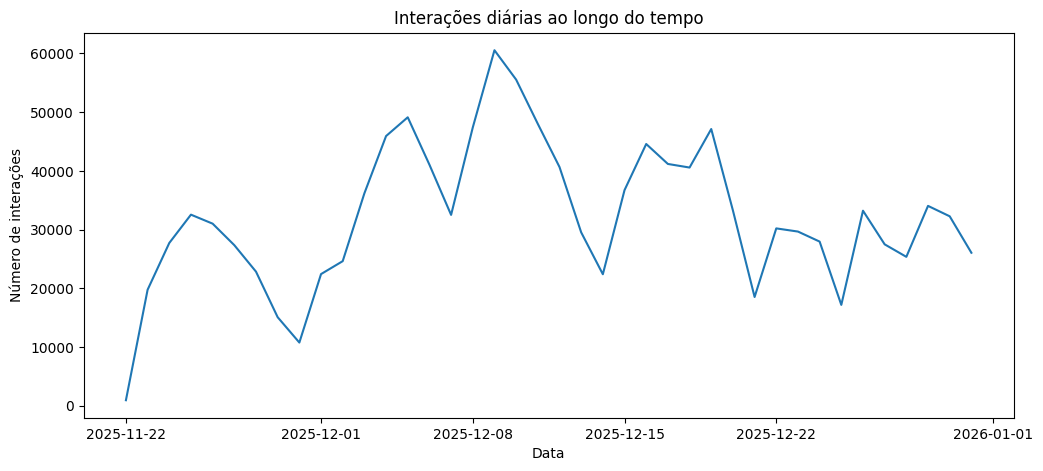

In [32]:
plt.figure(figsize=(12, 5))
daily_counts.plot()
plt.title('Interações diárias ao longo do tempo')
plt.xlabel('Data')
plt.ylabel('Número de interações')
plt.show()

## 14. Merge entre respostas e questões

Serve para validar consistência entre question_id e metadados das questões.

In [33]:
question_cols = [c for c in ['questionId', 'subjectId', 'institutionName', 'examYear', 'subjectAccumulatedNames'] if c in questions.columns]
merged = answers.merge(questions[question_cols], left_on='question_id', right_on='questionId', how='left')
merged_match_rate = merged['questionId'].notna().mean()
pd.Series({
    'merge_match_rate': merged_match_rate,
    'missing_question_metadata_rows': int(merged['questionId'].isna().sum()),
})

merge_match_rate                        0.0
missing_question_metadata_rows    1289900.0
dtype: float64

## 15. Principais achados

Preencher após execução final:

- balanceamento do target
- dispersão de interações por usuário
- caudas longas em tempo de resposta e recência
- concentração de respostas em poucas skills/H2
- cobertura do mapeamento skill -> H2
- implicações para DKT e LPKT

## Leituras esperadas
- `time_response` e `delta_t` devem justificar transformação logarítmica
- distribuição por usuário deve justificar filtragem mínima de interações
- análise por skill e H2 deve apoiar a decisão entre granularidade item-level e agregação temática
